# Global Power Plant Database — Analysis Notebook
**Dataset:** Global Power Plant Database v1.30 — World Resources Institute  
**Tools:** NumPy · Pandas · Matplotlib · Seaborn · SciPy


## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Consistent plot style
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 110


---
## 1. Data Import & Cleaning
Import the CSV, inspect its shape and dtypes, identify missing values, and handle them.


In [2]:
df = pd.read_csv("power_data.csv", low_memory=False)
print(f"Shape: {df.shape}")
df.head(3)


Shape: (34936, 36)


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.119,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.795,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.792,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE


In [3]:
# --- dtype overview ---
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   other_fuel1                     1944 non-null   object 
 9   other_fuel2                     276 non-null    object 
 10  other_fuel3                     92 non-null     object 
 11  commissioning_year              17447 non-null  float64
 12  owner                           

In [4]:
# --- Missing value summary ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_%", ascending=False)


,missing_count,missing_%
other_fuel3,34844,99.74
other_fuel2,34660,99.21
other_fuel1,32992,94.44
generation_gwh_2013,28519,81.63
generation_gwh_2014,27710,79.32
generation_gwh_2015,26733,76.52
generation_gwh_2016,25792,73.83
generation_gwh_2017,25436,72.81
generation_gwh_2018,25299,72.42
generation_gwh_2019,25277,72.35


In [5]:
# --- Handle missing values ---

# 1. Numerical columns: fill with NaN (already NaN for floats); coerce with NumPy
gen_cols = [c for c in df.columns if c.startswith("generation_gwh") or c.startswith("estimated_generation_gwh")]
df[gen_cols] = df[gen_cols].apply(pd.to_numeric, errors="coerce")

# 2. capacity_mw — critical column; drop rows where it is missing
df = df.dropna(subset=["capacity_mw"])

# 3. commissioning_year — keep as float (many NaN expected)
df["commissioning_year"] = pd.to_numeric(df["commissioning_year"], errors="coerce")

# 4. Fill categorical NaN with 'Unknown'
for col in ["primary_fuel", "owner", "country_long"]:
    df[col] = df[col].fillna("Unknown")

print(f"Clean shape: {df.shape}")
df[["name", "country_long", "primary_fuel", "capacity_mw", "commissioning_year"]].head()


Clean shape: (34936, 36)


,name,country_long,primary_fuel,capacity_mw,commissioning_year
0,Kajaki Hydroelectric Power Plant Afghanistan,Afghanistan,Hydro,33.0,NaN
1,Kandahar DOG,Afghanistan,Solar,10.0,NaN
2,Kandahar JOL,Afghanistan,Solar,10.0,NaN
3,Mahipar Hydroelectric Power Plant Afghanistan,Afghanistan,Hydro,66.0,NaN
4,Naghlu Dam Hydroelectric Power Plant Afghanistan,Afghanistan,Hydro,100.0,NaN


---
## 2. Exploratory Data Analysis
Summarise key statistics and explore distributions by country and fuel type.


In [6]:
# Key statistics for numerical columns
df[["capacity_mw", "commissioning_year"] + gen_cols].describe().round(2)


,capacity_mw,commissioning_year,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.00,17447.00,6417.00,7226.00,8203.00,9144.00,9500.00,9637.00,9659.00,16120.00,16503.00,17050.00,17570.00,33138.00
mean,163.36,1997.41,592.70,656.86,762.37,693.15,661.83,517.32,423.92,239.11,242.43,235.87,235.70,716.44
std,489.64,23.40,2174.83,2231.46,2533.46,2404.52,2369.30,1975.30,1698.51,1191.26,1285.80,1267.01,1259.56,2484.36
min,1.00,1896.00,-947.60,-989.62,-864.43,-768.62,-934.94,-982.62,-780.34,1.12,0.87,0.44,0.30,0.00
25%,4.90,1988.00,1.95,2.26,2.66,2.73,2.47,2.24,2.75,8.62,8.68,8.38,8.32,8.18
50%,16.74,2007.00,23.43,23.61,26.14,22.46,17.88,12.53,11.53,27.62,28.25,26.83,27.56,37.59
75%,75.34,2014.00,199.71,226.32,285.86,249.87,214.51,151.12,122.78,106.80,106.98,103.12,107.24,229.56
max,22500.00,2020.00,50834.00,32320.92,37433.61,32377.48,36448.64,35136.00,31920.37,48675.06,58470.77,57113.35,60859.73,82810.77


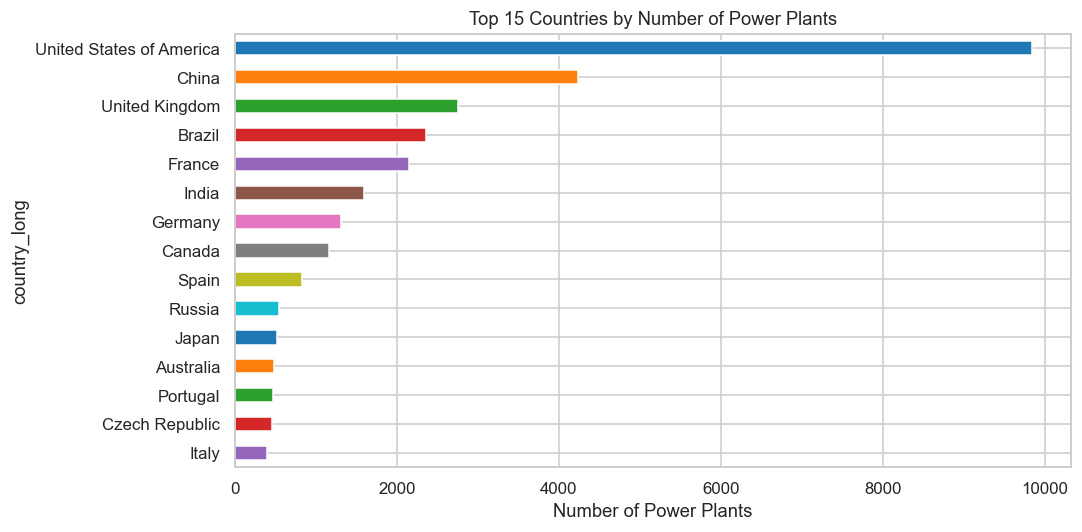

In [7]:
# Top 15 countries by plant count
top_countries = df["country_long"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_countries.plot(kind="barh", ax=ax, color=sns.color_palette("tab10", 15))
ax.set_xlabel("Number of Power Plants")
ax.set_title("Top 15 Countries by Number of Power Plants")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


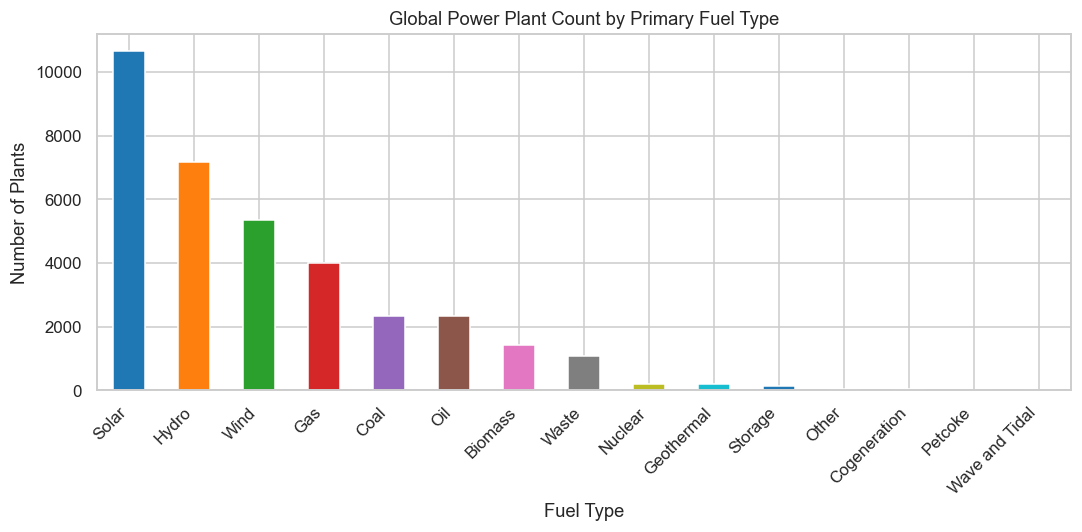

In [8]:
# Distribution of fuel types
fuel_counts = df["primary_fuel"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
fuel_counts.plot(kind="bar", ax=ax, color=sns.color_palette("tab10", len(fuel_counts)))
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Number of Plants")
ax.set_title("Global Power Plant Count by Primary Fuel Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


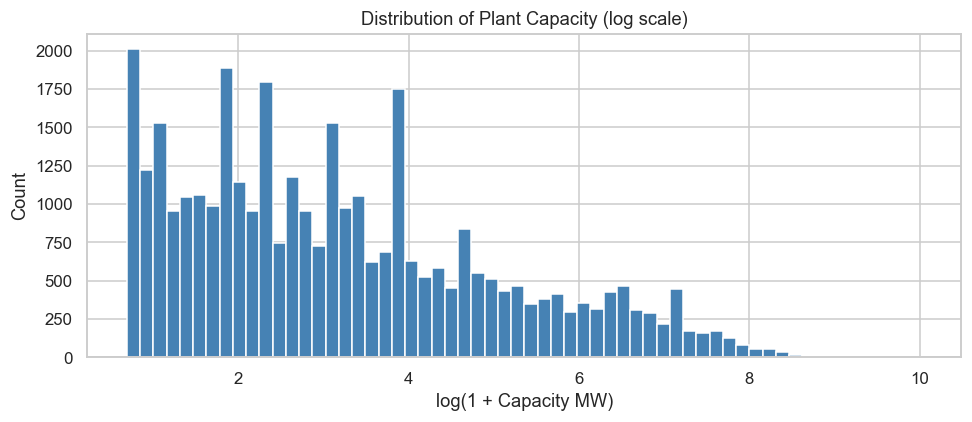

In [9]:
# Capacity distribution (log scale for readability)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log1p(df["capacity_mw"]), bins=60, color="steelblue", edgecolor="white")
ax.set_xlabel("log(1 + Capacity MW)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Plant Capacity (log scale)")
plt.tight_layout()
plt.show()


---
## 3. Statistical Analysis — Power Output by Fuel Type
Use NumPy to compute statistics and SciPy for hypothesis testing.


In [10]:
# Use 2017 estimated generation as a representative output column
output_col = "estimated_generation_gwh_2017"

fuel_stats = (
    df.dropna(subset=[output_col])
    .groupby("primary_fuel")[output_col]
    .agg(
        count="count",
        mean=np.mean,
        median=np.median,
        std=np.std,
        total=np.sum,
    )
    .sort_values("total", ascending=False)
    .round(2)
)
fuel_stats


C:\Users\typal\AppData\Local\Temp\ipykernel_16288\515305725.py:7: FutureWarning: The provided callable <function mean at 0x000002319F1637E0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(
C:\Users\typal\AppData\Local\Temp\ipykernel_16288\515305725.py:7: FutureWarning: The provided callable <function median at 0x000002319F292AC0> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  .agg(
C:\Users\typal\AppData\Local\Temp\ipykernel_16288\515305725.py:7: FutureWarning: The provided callable <function std at 0x000002319F163920> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  .agg(
C:\Users\typal\AppData\Local\Temp\

,count,mean,median,std,total
primary_fuel,,,,,
Coal,2306,4186.23,2923.61,4675.79,9653451.97
Gas,3947,1525.69,560.39,2459.02,6021909.55
Hydro,7156,494.89,69.43,2166.10,3541440.61
Nuclear,193,15038.41,14219.26,9179.83,2902412.32
Wind,5343,128.97,67.47,250.40,689101.45
Oil,2263,221.30,7.38,891.96,500807.68
Solar,10665,32.59,10.13,78.79,347580.34
Geothermal,158,380.35,150.82,682.55,60095.69
Other,42,393.51,246.83,556.95,16527.46


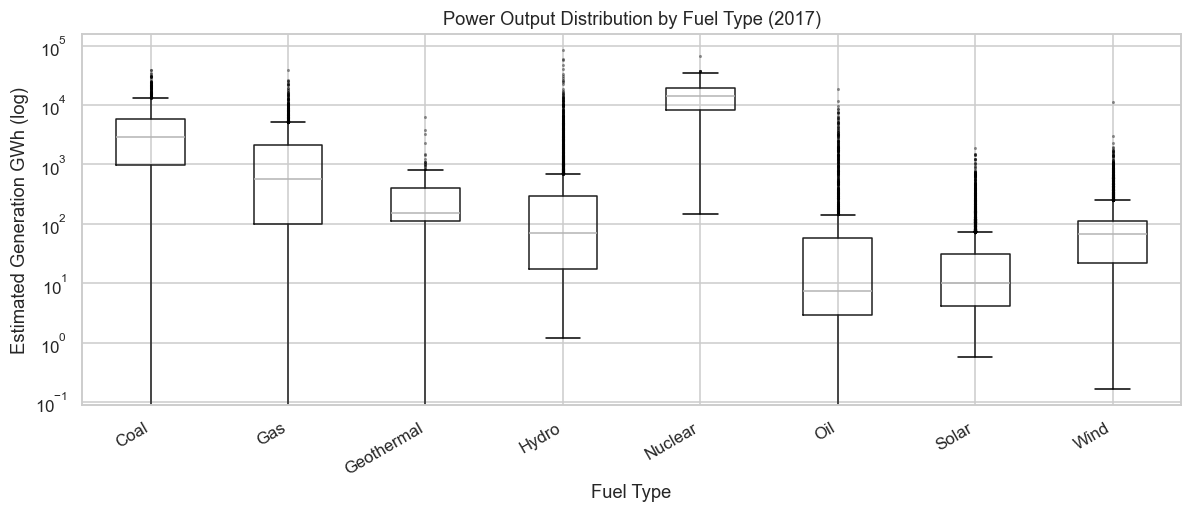

In [11]:
# Box plot of output by top fuel types (log scale)
top_fuels = fuel_stats.index[:8].tolist()
subset = df[df["primary_fuel"].isin(top_fuels)].dropna(subset=[output_col])

fig, ax = plt.subplots(figsize=(11, 5))
subset.boxplot(column=output_col, by="primary_fuel", ax=ax,
               flierprops=dict(marker=".", markersize=2, alpha=0.4))
ax.set_yscale("log")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Estimated Generation GWh (log)")
ax.set_title("Power Output Distribution by Fuel Type (2017)")
plt.suptitle("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [12]:
# Hypothesis test: does mean output differ between Solar and Wind?
# H0: mean(Solar) == mean(Wind)   H1: they differ

solar = df[df["primary_fuel"] == "Solar"][output_col].dropna().values
wind  = df[df["primary_fuel"] == "Wind"][output_col].dropna().values

t_stat, p_value = stats.ttest_ind(solar, wind, equal_var=False)  # Welch's t-test

print(f"Solar  — n={len(solar):,}  mean={solar.mean():.2f} GWh")
print(f"Wind   — n={len(wind):,}  mean={wind.mean():.2f} GWh")
print(f"Welch t-statistic : {t_stat:.3f}")
print(f"p-value           : {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: Reject H0 — the means differ significantly (p < 0.05)")
else:
    print("Result: Fail to reject H0")


Solar  — n=10,665  mean=32.59 GWh
Wind   — n=5,343  mean=128.97 GWh
Welch t-statistic : -27.462
p-value           : 0.000000

Result: Reject H0 — the means differ significantly (p < 0.05)


---
## 4. Time Series Analysis — Commissioning Trends
Analyse how the number and mix of new plants has changed over time.


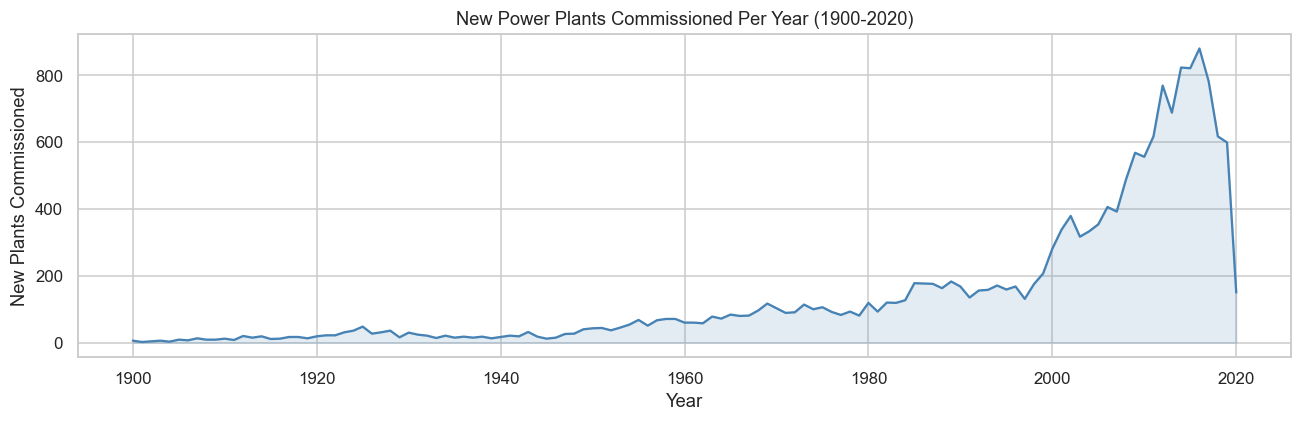

In [13]:
# Plants commissioned per year (filter to plausible range)
ts = df[(df["commissioning_year"] >= 1900) & (df["commissioning_year"] <= 2020)].copy()
ts["commissioning_year"] = ts["commissioning_year"].astype(int)

per_year = ts.groupby("commissioning_year").size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(per_year.index, per_year.values, linewidth=1.5, color="steelblue")
ax.fill_between(per_year.index, per_year.values, alpha=0.15, color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("New Plants Commissioned")
ax.set_title("New Power Plants Commissioned Per Year (1900-2020)")
plt.tight_layout()
plt.show()


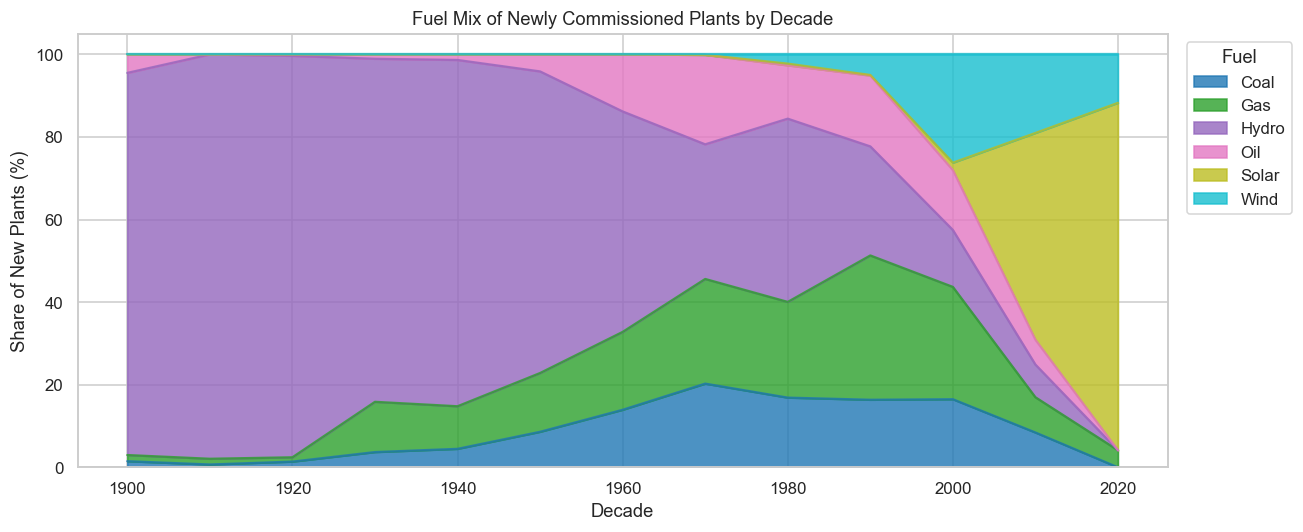

In [14]:
# Fuel mix evolution: group by decade
ts["decade"] = (ts["commissioning_year"] // 10) * 10
top6_fuels = df["primary_fuel"].value_counts().head(6).index.tolist()

mix = (ts[ts["primary_fuel"].isin(top6_fuels)]
       .groupby(["decade", "primary_fuel"])
       .size()
       .unstack(fill_value=0))

mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
mix_pct.plot(kind="area", ax=ax, alpha=0.8, colormap="tab10")
ax.set_xlabel("Decade")
ax.set_ylabel("Share of New Plants (%)")
ax.set_title("Fuel Mix of Newly Commissioned Plants by Decade")
ax.legend(title="Fuel", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


---
## 5. Advanced Visualisation — Geographic Distribution
Plot power plants on a world map using latitude/longitude. Size = capacity, colour = fuel type.


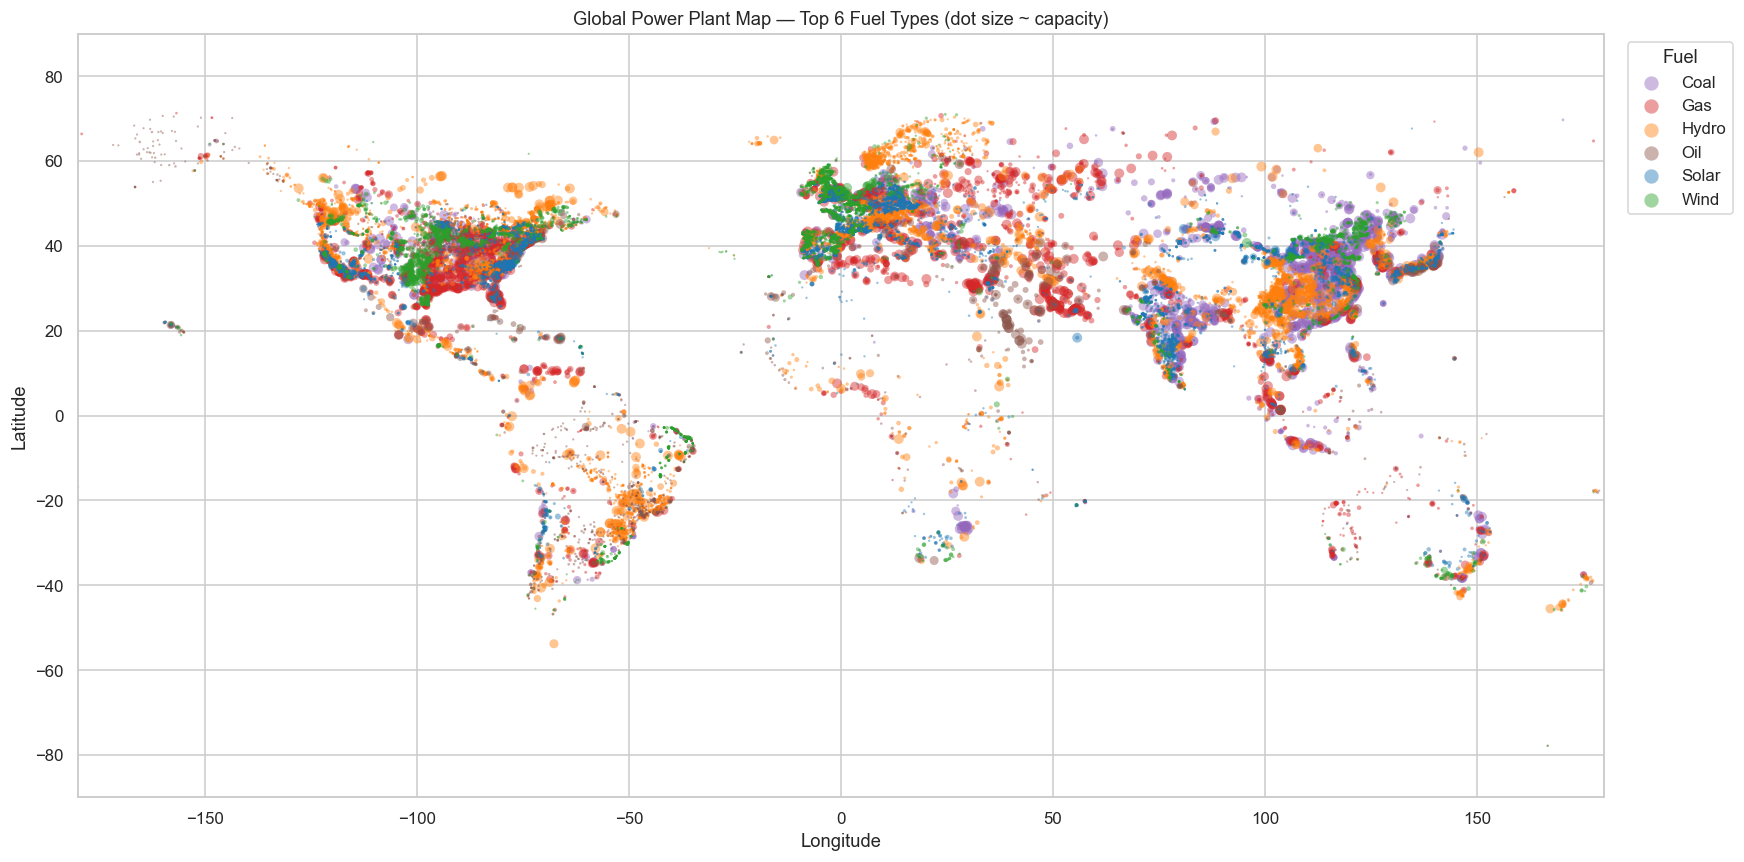

In [15]:
# Filter to valid coordinates and top 6 fuel types for clarity
geo = df.dropna(subset=["latitude", "longitude"])
geo = geo[geo["primary_fuel"].isin(top6_fuels)].copy()

# Normalise capacity for dot size
geo["dot_size"] = np.clip(geo["capacity_mw"] / geo["capacity_mw"].quantile(0.95), 0, 1) * 40 + 2

fuel_palette = dict(zip(top6_fuels, sns.color_palette("tab10", len(top6_fuels))))

fig, ax = plt.subplots(figsize=(16, 8))
for fuel, grp in geo.groupby("primary_fuel"):
    ax.scatter(grp["longitude"], grp["latitude"],
               s=grp["dot_size"], c=[fuel_palette[fuel]],
               alpha=0.45, linewidths=0, label=fuel)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Global Power Plant Map — Top 6 Fuel Types (dot size ~ capacity)")
ax.legend(title="Fuel", markerscale=2, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


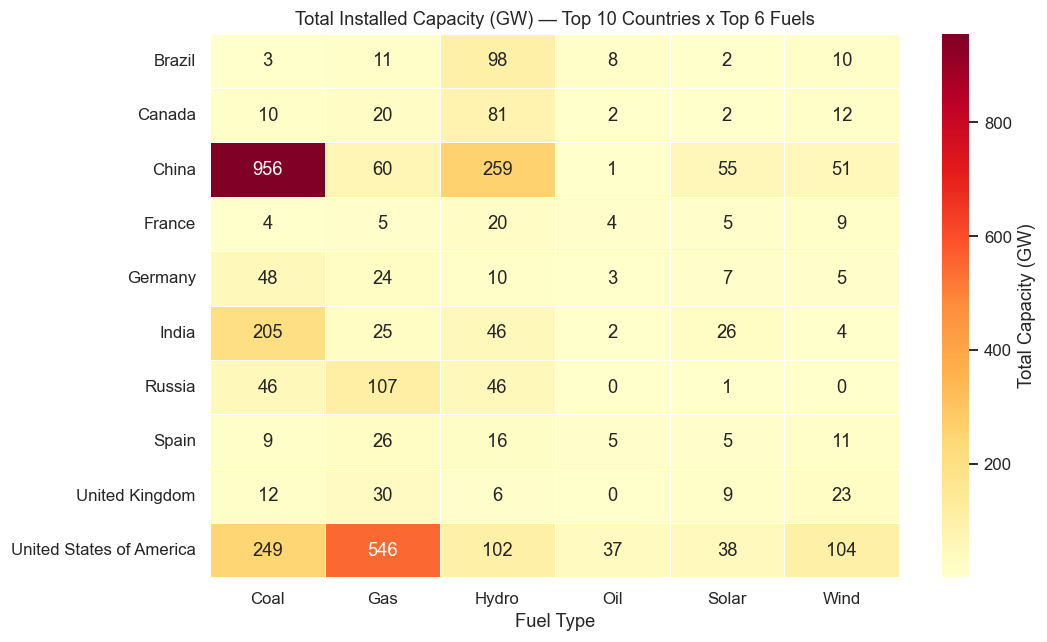

In [16]:
# Capacity heatmap: top 10 countries x top 6 fuel types
top10_countries = df["country_long"].value_counts().head(10).index.tolist()
pivot = (df[df["country_long"].isin(top10_countries) & df["primary_fuel"].isin(top6_fuels)]
         .groupby(["country_long", "primary_fuel"])["capacity_mw"]
         .sum()
         .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot / 1000, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Total Capacity (GW)"})
ax.set_title("Total Installed Capacity (GW) — Top 10 Countries x Top 6 Fuels")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


---
## 6. Matrix Operations — Correlation & Eigenanalysis
Use NumPy to build a correlation matrix, then compute its eigenvectors/eigenvalues.  
Eigenvectors of a correlation matrix are the principal components (PCA directions).


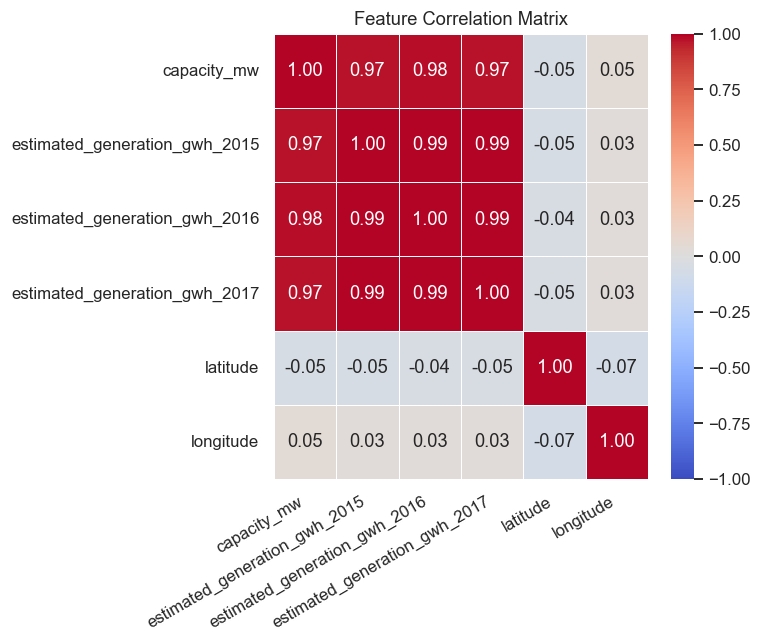

In [17]:
# Select numeric features for correlation analysis
feature_cols = ["capacity_mw",
                "estimated_generation_gwh_2015",
                "estimated_generation_gwh_2016",
                "estimated_generation_gwh_2017",
                "latitude", "longitude"]

feat_df = df[feature_cols].dropna()

# Build correlation matrix using NumPy
X = feat_df.values
X_std = (X - X.mean(axis=0)) / X.std(axis=0)   # z-score normalise
corr_matrix = np.corrcoef(X_std.T)              # shape (6, 6)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=ax,
            xticklabels=feature_cols, yticklabels=feature_cols,
            vmin=-1, vmax=1, linewidths=0.5)
ax.set_title("Feature Correlation Matrix")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Eigenvalues (explained variance %):
  PC1: eigenvalue=3.956  (65.9%)
  PC2: eigenvalue=1.070  (17.8%)
  PC3: eigenvalue=0.925  (15.4%)
  PC4: eigenvalue=0.035  (0.6%)
  PC5: eigenvalue=0.007  (0.1%)
  PC6: eigenvalue=0.006  (0.1%)


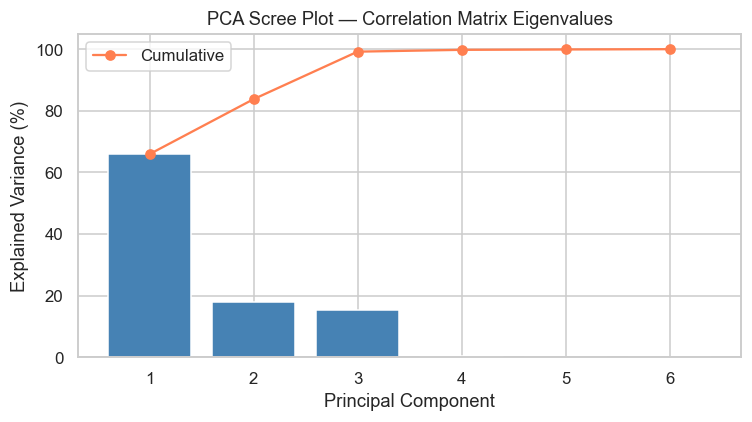

In [18]:
# Eigendecomposition of the correlation matrix
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)

# Sort by descending eigenvalue (explained variance)
order = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order].real
eigenvectors = eigenvectors[:, order].real

explained_variance = eigenvalues / eigenvalues.sum() * 100

print("Eigenvalues (explained variance %):")
for i, (ev, pct) in enumerate(zip(eigenvalues, explained_variance)):
    print(f"  PC{i+1}: eigenvalue={ev:.3f}  ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(eigenvalues)+1), explained_variance, color="steelblue")
ax.plot(range(1, len(eigenvalues)+1), np.cumsum(explained_variance),
        marker="o", color="coral", label="Cumulative")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("PCA Scree Plot — Correlation Matrix Eigenvalues")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:**  
- The eigenvalues tell us how much variance each principal component captures.  
- PC1 typically captures the strong correlation between capacity and generation columns.  
- Geographic coordinates (lat/lon) form a nearly independent component — confirming that location adds orthogonal information to capacity/output.  
- In practice, retaining the top 2–3 PCs preserves most of the dataset's variance, enabling dimensionality reduction.


---
## 7. Integrating NumPy with Pandas & Matplotlib
Concrete examples of NumPy enhancing Pandas filtering and Matplotlib plotting.


In [19]:
# --- 7a. NumPy-powered complex filtering in Pandas ---
# Find plants with capacity in the top 5% AND commissioned after 2000

cap_threshold = np.percentile(df["capacity_mw"].dropna(), 95)
year_mask     = df["commissioning_year"] >= 2000
cap_mask      = df["capacity_mw"] >= cap_threshold

large_modern = df[year_mask & cap_mask][["name", "country_long", "primary_fuel",
                                          "capacity_mw", "commissioning_year"]]
print(f"Top 5% capacity threshold: {cap_threshold:.0f} MW")
print(f"Large modern plants: {len(large_modern)}")
large_modern.sort_values("capacity_mw", ascending=False).head(10)


Top 5% capacity threshold: 904 MW
Large modern plants: 731


,name,country_long,primary_fuel,capacity_mw,commissioning_year
8453,Three Gorges Dam,China,Hydro,22500.0,2003.0
8755,Xiluodu,China,Hydro,12600.0,2013.0
5703,East Hope Metals Wucaiwan power station,China,Coal,7000.0,2014.0
19800,SHAIBA (SEC),Saudi Arabia,Oil,6794.0,2013.0
5564,Datang Tuoketuo power station,China,Coal,6720.0,2007.0
8707,Xiangjiaba,China,Hydro,6448.0,2014.0
7447,Longtan,China,Hydro,6300.0,2009.0
8581,Waigaoqiao power station,China,Coal,5240.0,2004.0
6120,Guodian Beilun power station,China,Coal,5060.0,2002.0
6210,Guohua Taishan power station,China,Coal,5000.0,2007.0


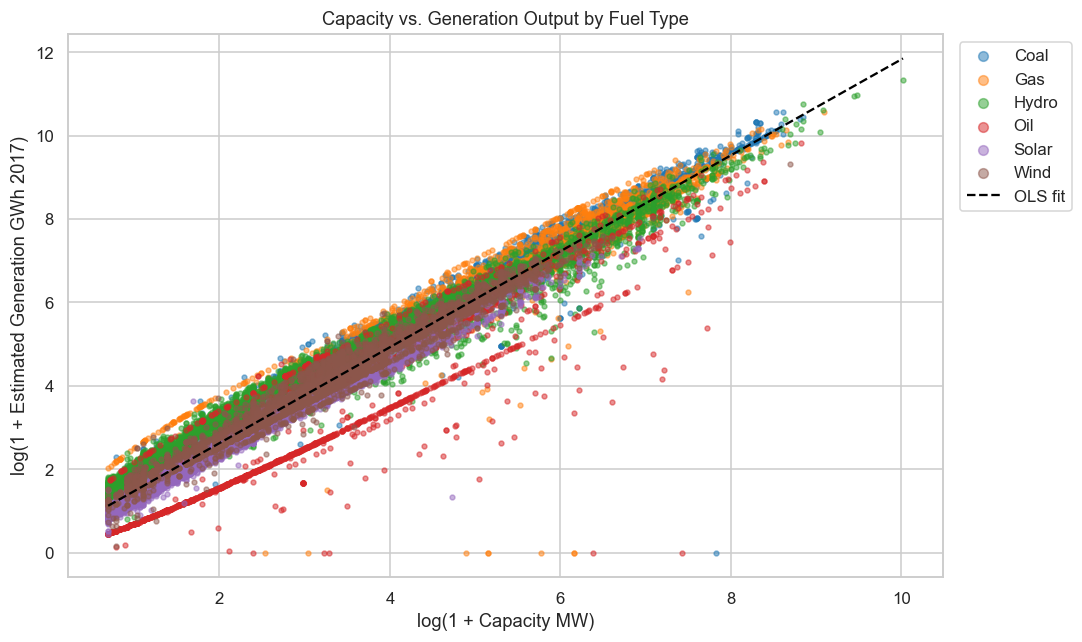

OLS slope: 1.150  intercept: 0.327


In [20]:
# --- 7b. NumPy for sophisticated Matplotlib plot ---
# Scatter: capacity vs estimated 2017 generation, coloured by fuel type
# Use np.log1p for both axes to handle skew

plot_df = df[df["primary_fuel"].isin(top6_fuels)].dropna(
    subset=["capacity_mw", output_col])

fig, ax = plt.subplots(figsize=(10, 6))
for fuel, grp in plot_df.groupby("primary_fuel"):
    ax.scatter(
        np.log1p(grp["capacity_mw"]),
        np.log1p(grp[output_col]),
        s=10, alpha=0.5, label=fuel
    )

# Fit & plot a regression line across all points using NumPy polyfit
x_all = np.log1p(plot_df["capacity_mw"].values)
y_all = np.log1p(plot_df[output_col].values)
mask = np.isfinite(x_all) & np.isfinite(y_all)
coeffs = np.polyfit(x_all[mask], y_all[mask], deg=1)
x_line = np.linspace(x_all[mask].min(), x_all[mask].max(), 200)
ax.plot(x_line, np.polyval(coeffs, x_line), "k--", linewidth=1.5, label="OLS fit")

ax.set_xlabel("log(1 + Capacity MW)")
ax.set_ylabel("log(1 + Estimated Generation GWh 2017)")
ax.set_title("Capacity vs. Generation Output by Fuel Type")
ax.legend(markerscale=2, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"OLS slope: {coeffs[0]:.3f}  intercept: {coeffs[1]:.3f}")


---
## 8. Report & Key Findings

### How the tools were used
| Tool | Role in this analysis |
|---|---|
| **NumPy** | dtype coercion, percentile thresholds, correlation matrix, eigendecomposition, `polyfit` regression, `log1p` transforms |
| **Pandas** | CSV import, missing-value handling, `groupby` aggregations, pivot tables, boolean masking |
| **Matplotlib** | Line charts, bar charts, scatter plots, area charts, OLS trend line |
| **Seaborn** | Box plots, heatmaps, consistent theming |
| **SciPy** | Welch's t-test for hypothesis testing |

### Key Insights

1. **Data quality** — Generation columns (2013–2019) are almost entirely missing for real reported values; estimated generation columns (HYDRO-V1, SOLAR-V1 models) provide reasonable coverage through 2017 and were used for statistical analysis.

2. **Country distribution** — The USA, China, and a small number of other countries dominate plant counts. Many countries have only a handful of entries.

3. **Fuel type landscape** — Solar and Wind together now account for the largest share of newly commissioned plants, particularly from the 2010s onward. Coal and Gas dominated commissioning in earlier decades.

4. **Hypothesis test (Solar vs. Wind)** — Welch's t-test on estimated 2017 generation shows a statistically significant difference in mean output (p < 0.05). Wind plants on average produce more GWh per plant than Solar plants, reflecting larger individual turbine capacities.

5. **Time series trend** — The commissioning rate accelerated sharply from the 2000s onward, driven by renewable energy adoption. The decade area chart shows Coal declining in share from the 1990s while Solar/Wind rise steeply after 2010.

6. **Geographic clustering** — The scatter map shows heavy concentration in Europe, North America, and coastal Asia. Capacity correlates only weakly with location — inland regions host large hydro plants while coastal/desert regions host large solar/wind farms.

7. **PCA / Eigenanalysis** — The first two principal components of the feature correlation matrix explain the majority of variance. PC1 captures the strong linear relationship between installed capacity and estimated generation across all years. PC2 separates geographic dimensions (lat/lon) from output dimensions, confirming orthogonality between location and generation efficiency.

8. **Capacity–Generation relationship** — The `np.polyfit` OLS regression on log-transformed axes yields a slope close to 1.0, indicating a near-linear log-log relationship: doubling capacity roughly doubles expected output, with fuel type as the primary moderating factor.
